Some easy stats can be pulled from the dataset, already those counts need investigation.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('AssessmentData/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


Unsurprisingly the dataset contains some entries that will need attention before our analysis proper.

In [3]:
df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

## Moments
We can forget Gaussian distribution, the stats suggest the pollution stats all have a positive skew; while CO and SO2 has significant tails.

In [36]:
for i in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']:
    print(f'Component {i}\tmean: {df[i].mean():.2f}\tvariance: {df[i].std()**2:.2f}\tskew: {df[i].skew():.2f}\tkurtosis: {df[i].kurtosis():.2f}\tmedian: {df[i].median():.2f}')

Component PM2.5	mean: 82.77	variance: 6746.27	skew: 1.97	kurtosis: 5.57	median: 58.00
Component PM10	mean: 110.06	variance: 9067.42	skew: 1.78	kurtosis: 5.38	median: 87.00
Component SO2	mean: 17.38	variance: 520.89	skew: 2.80	kurtosis: 10.79	median: 9.00
Component NO2	mean: 59.31	variance: 1377.61	skew: 0.93	kurtosis: 1.04	median: 53.00
Component CO	mean: 1262.95	variance: 1491906.48	skew: 2.56	kurtosis: 8.81	median: 900.00
Component O3	mean: 56.35	variance: 3354.30	skew: 1.44	kurtosis: 2.18	median: 42.00


Which can be visualised by some lovely distributions. The question will be do all (or at least the 4 chosen) follow the same distributions. The visualisation throws up some intersting artifacts to investigate in NO2 and O3. 

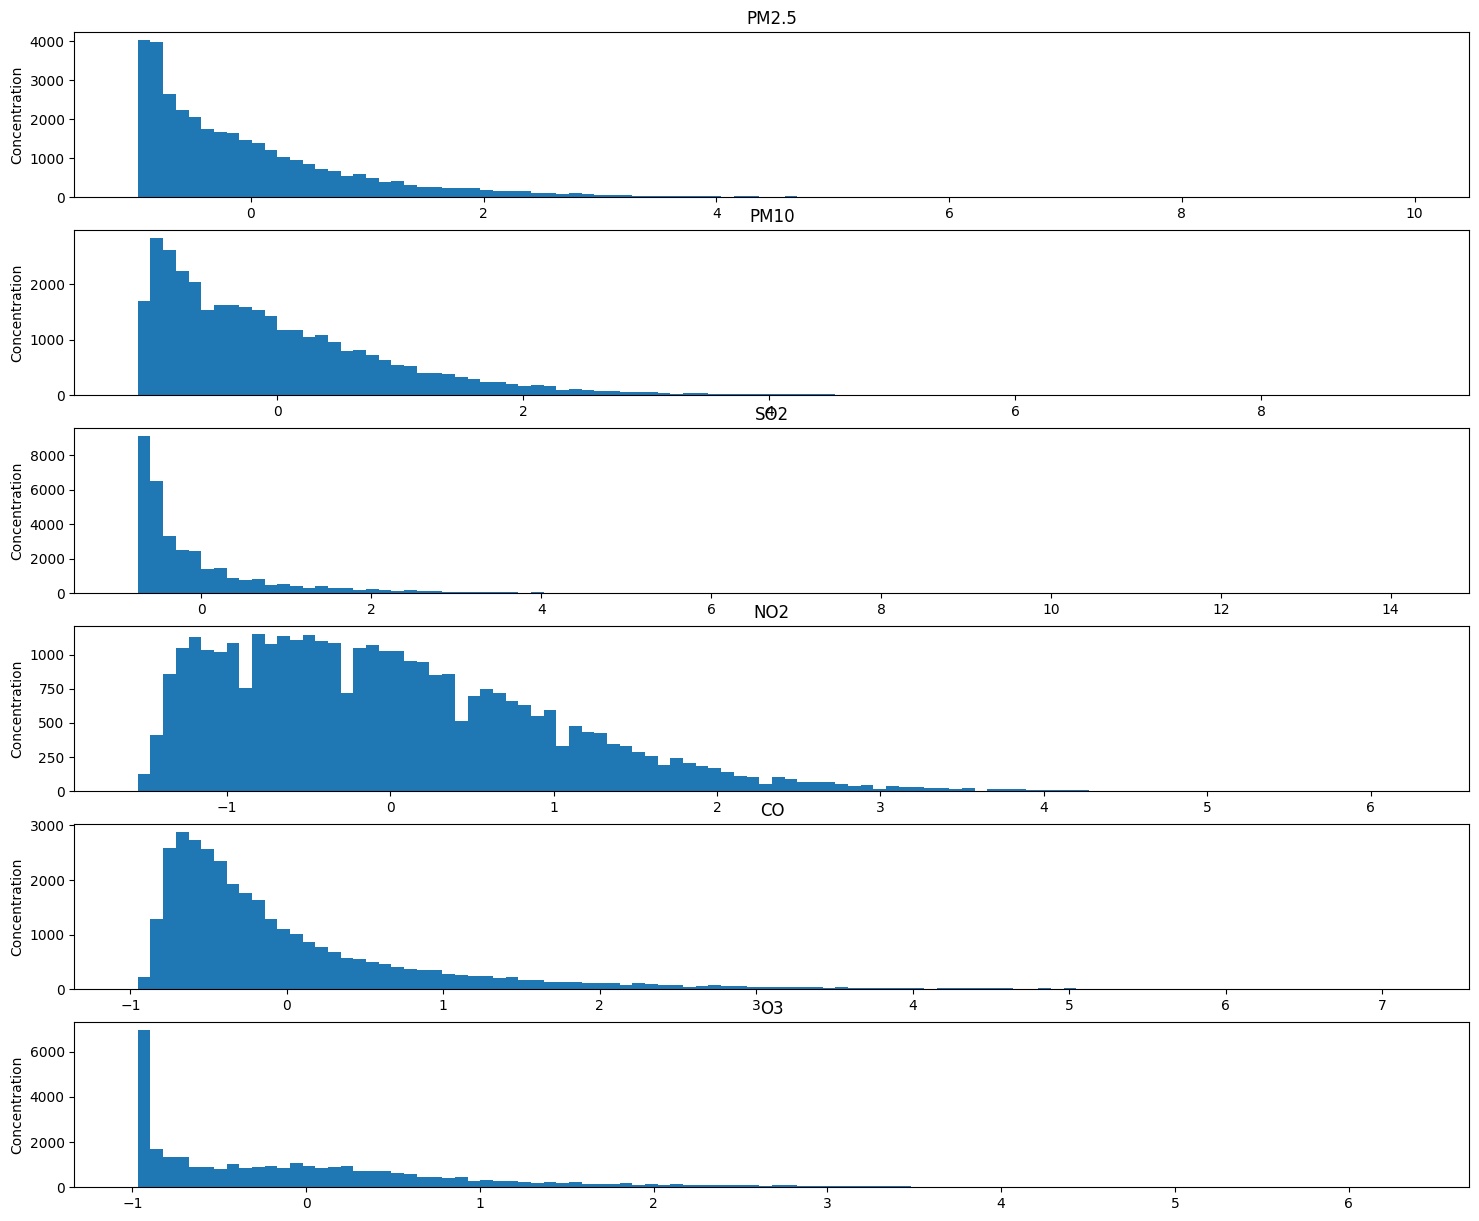

In [ ]:
fig, ax = plt.subplots(6, 1, figsize=(18, 15))#, sharex=True)

for i, v in enumerate(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']):
    ax[i].hist((df[v]-df[v].mean())/df[v].std(), bins=100)
    ax[i].set(title=v,
            ylabel='Concentration')

plt.show()